In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pathlib import Path

In [35]:
CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
DATA_DIR = PARENT_DIR / "T04_preprocess"
print(CURRENT_DIR)
print(DATA_DIR)

c:\Users\admin\Coding\research\weld-ml\src\P02_data\T05_EA
c:\Users\admin\Coding\research\weld-ml\src\P02_data\T04_preprocess


In [36]:
sns.set_theme(style="whitegrid", context="talk")

In [37]:
filepath = os.path.join(
    DATA_DIR, "./S02/S02_residual_stress_imputed_20260104_114536.xlsx"
)
dfm = pd.read_excel(filepath)
dfm

,idx_excel_post,section,sample_no,location,R,W,D,sigma_x_post,FWHM_post,idx_excel_pre,sigma_x_pre,FWHM_pre,diff_sigma_x
0,4,AA5052,1,1,1400,60,10,13.0,2.55,2,-15.0,2.50,28.0
1,25,AA5052,2,1,1400,60,15,16.0,2.51,9,2.0,2.47,14.0
2,46,AA5052,3,1,1400,60,20,19.0,2.47,16,9.0,2.48,10.0
3,67,AA5052,4,1,1400,70,10,20.0,2.45,23,10.0,2.48,10.0
4,88,AA5052,5,1,1400,70,15,6.0,2.47,30,0.0,2.49,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,1050,Center,50,7,1600,70,15,2.0,2.45,0,0.0,0.00,2.0
1130,1071,Center,51,7,1600,70,20,2.0,2.45,0,0.0,0.00,2.0
1131,1092,Center,52,7,1600,80,10,5.0,2.54,0,0.0,0.00,5.0
1132,1113,Center,53,7,1600,80,15,1.0,2.41,0,0.0,0.00,1.0


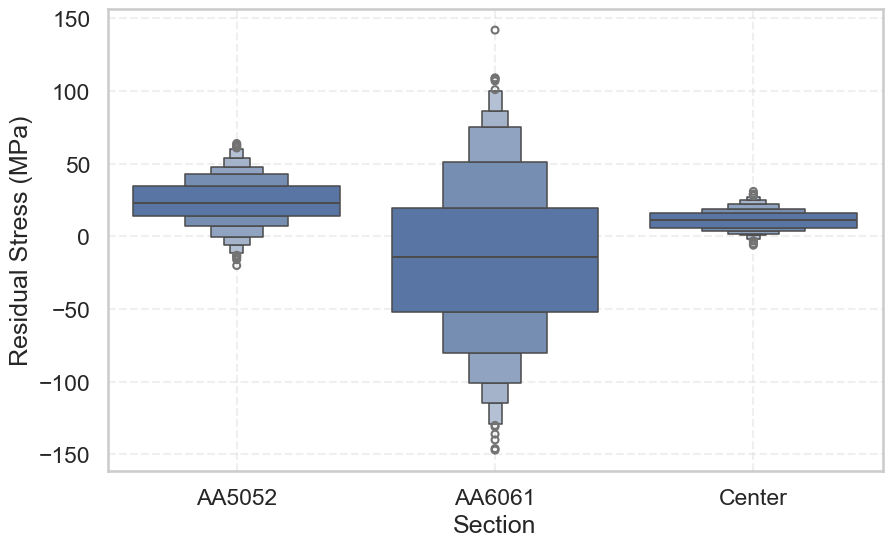

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxenplot(data=dfm, x="section", y="diff_sigma_x", ax=ax)
# ax.set_title("Residual Stress vs Section by R")
ax.set_xlabel("Section")
ax.set_ylabel("Residual Stress (MPa)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
plt.savefig("stress_section.png", dpi=300, bbox_inches="tight")

In [39]:
dfm.groupby("sample_no")["diff_sigma_x"].agg(["mean", "std", "count"]).sort_values(
    "mean", ascending=True
)

,mean,std,count
sample_no,,,
40,-13.095238,34.292718,21
6,-9.714286,34.935860,21
39,-7.000000,51.902794,21
20,-6.190476,45.824250,21
30,-4.000000,50.268280,21
41,-4.000000,45.134244,21
37,-3.948787,39.613896,21
29,-2.523810,45.082834,21
10,-2.476190,30.733726,21


,mean,std,count
sample_no,,,
40,-2.714286,9.928314,7
6,0.285714,13.009154,7
50,5.571429,8.521681,7
45,6.142857,10.991339,7
44,8.714286,7.825477,7
5,10.000000,3.109126,7
3,11.857143,7.057586,7
2,12.000000,14.433757,7
51,12.215633,18.610667,7


C:\Users\admin\AppData\Local\Temp\ipykernel_17156\1348533551.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sample_labels, rotation=45, ha="right")


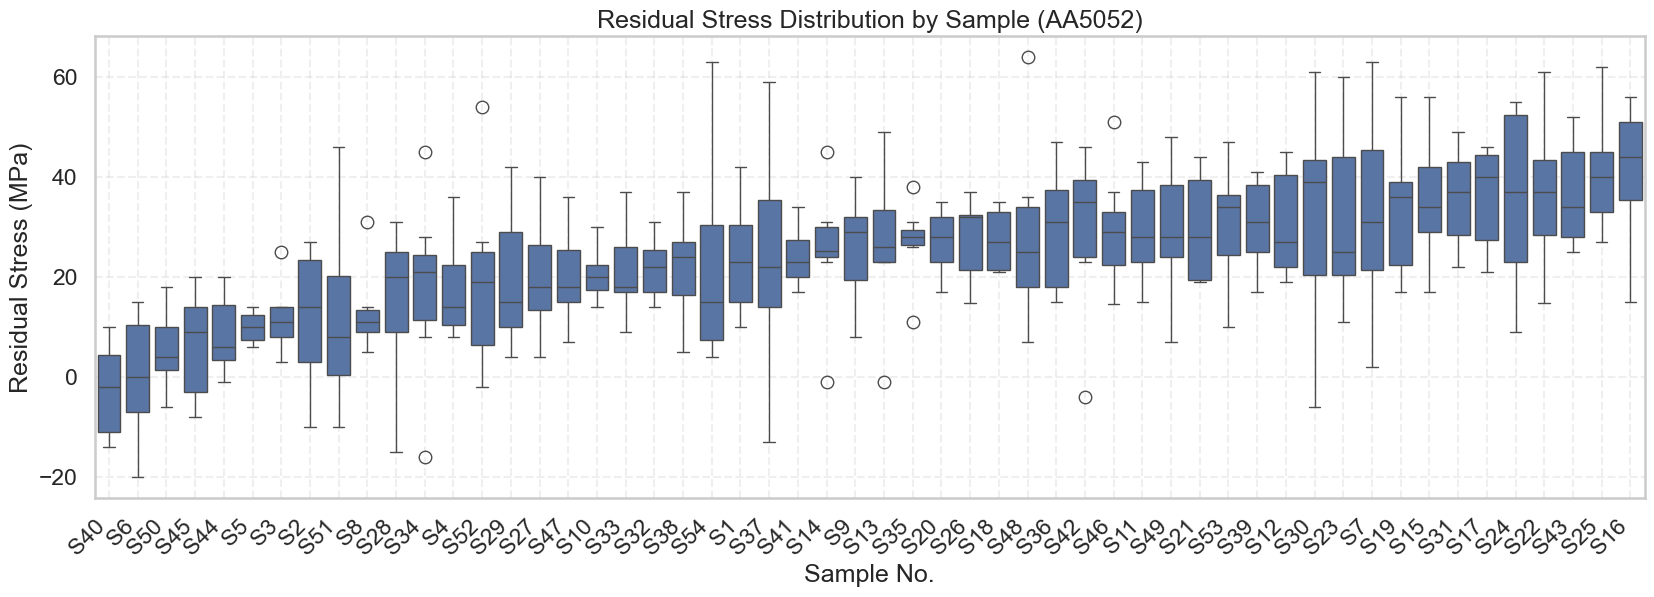

In [43]:
filter_region = ["AA5052"]

# Filter region
filtered_df = dfm[dfm["section"].isin(filter_region)]
# Rank samples by mean residual stress
rank_df = (
    filtered_df.groupby("sample_no")["diff_sigma_x"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
display(rank_df)

# X Tick labels for boxplot
sample_labels = rank_df.index.tolist()
sample_labels = [f"S{i}" for i in sample_labels]


# Plot boxplot with samples ordered by mean residual stress
best_sample_order = rank_df.sort_values(by="mean", ascending=True).index
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=filtered_df, x="sample_no", y="diff_sigma_x", order=best_sample_order)
ax.set_xlabel("Sample No.")
ax.set_ylabel("Residual Stress (MPa)")
ax.set_xticklabels(sample_labels, rotation=45, ha="right")
# Add title and labels
ax.set_title("Residual Stress Distribution by Sample (AA5052)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
plt.savefig("stress_sample_AA5052.png", dpi=300, bbox_inches="tight")


,mean,std,count
sample_no,,,
39,-61.000000,59.152346,7
30,-55.571429,54.732249,7
20,-53.428571,52.961801,7
41,-45.714286,59.653763,7
19,-44.142857,43.379829,7
40,-43.142857,46.616980,7
37,-41.857143,44.584858,7
53,-40.142857,56.090488,7
6,-38.142857,49.235585,7


C:\Users\admin\AppData\Local\Temp\ipykernel_17156\251486869.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sample_labels, rotation=45, ha="right")


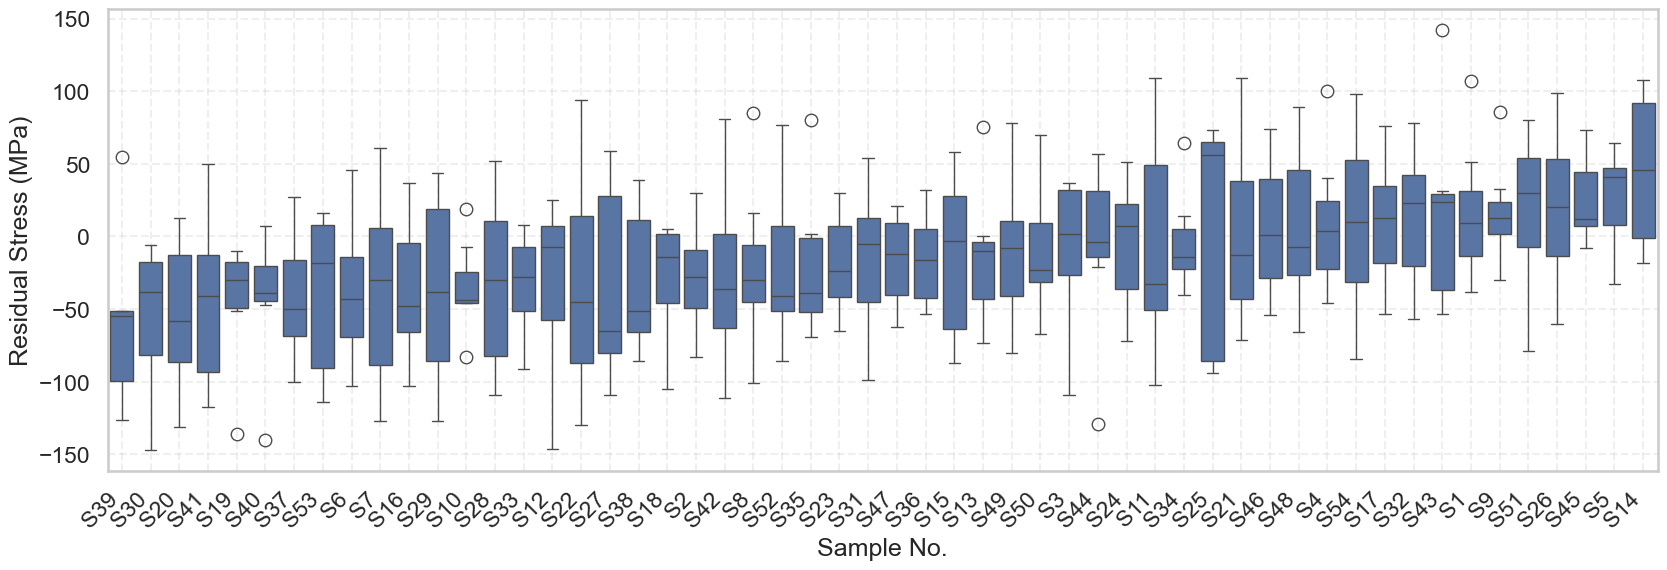

In [ ]:
filter_region = ["AA6061"]

# Filter region
filtered_df = dfm[dfm["section"].isin(filter_region)]
# Rank samples by mean residual stress
rank_df = (
    filtered_df.groupby("sample_no")["diff_sigma_x"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
display(rank_df)

# X Tick labels for boxplot
sample_labels = rank_df.index.tolist()
sample_labels = [f"S{i}" for i in sample_labels]


# Plot boxplot with samples ordered by mean residual stress
best_sample_order = rank_df.sort_values(by="mean", ascending=True).index
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=filtered_df, x="sample_no", y="diff_sigma_x", order=best_sample_order)
ax.set_xlabel("Sample No.")
ax.set_ylabel("Residual Stress (MPa)")
ax.set_xticklabels(sample_labels, rotation=45, ha="right")
# Add title and labels
ax.set_title("Residual Stress Distribution by Sample (AA6061)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
plt.savefig("stress_sample_AA6061.png", dpi=300, bbox_inches="tight")

,mean,std,count
sample_no,,,
51,4.857143,5.177791,7
37,6.153639,5.796481,7
40,6.571429,4.237025,7
47,7.000000,4.434712,7
50,7.000000,4.434712,7
46,7.142857,4.375255,7
49,7.428571,3.309438,7
10,7.571429,6.654751,7
20,7.714286,4.750940,7


C:\Users\admin\AppData\Local\Temp\ipykernel_17156\166689675.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sample_labels, rotation=45, ha="right")


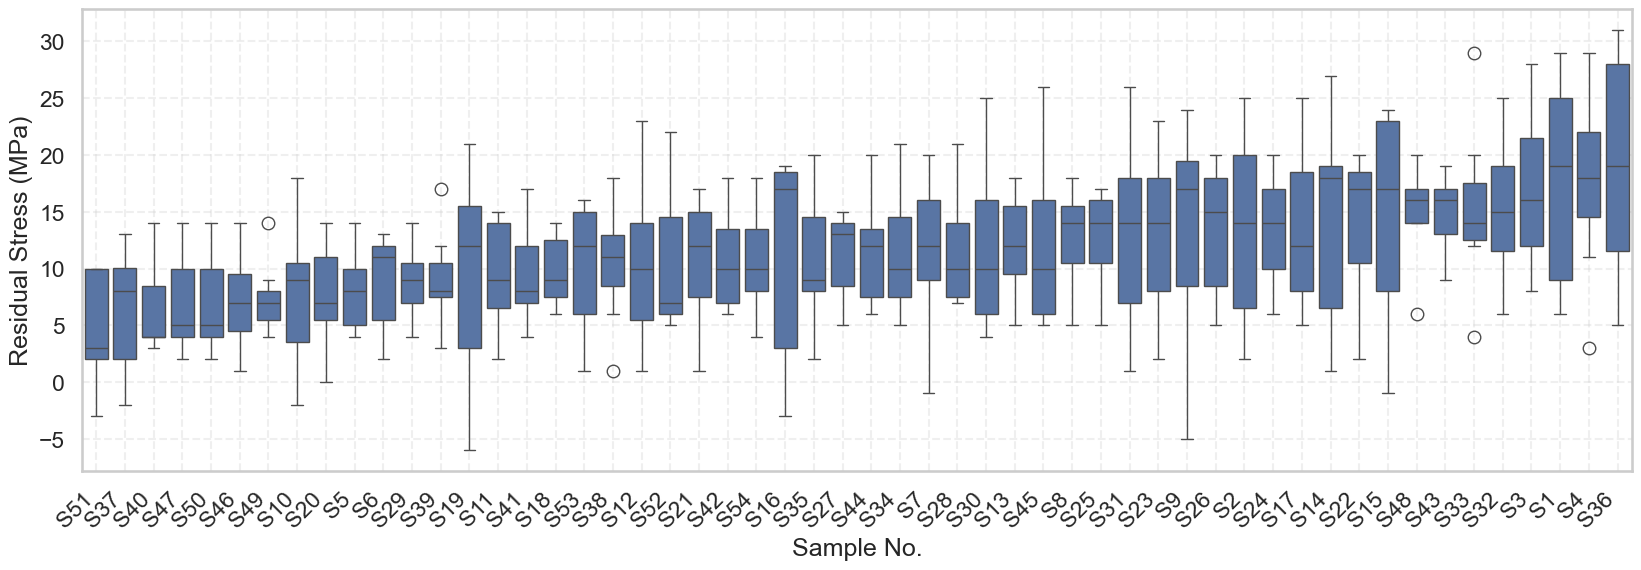

In [ ]:
filter_region = ["Center"]

# Filter region
filtered_df = dfm[dfm["section"].isin(filter_region)]
# Rank samples by mean residual stress
rank_df = (
    filtered_df.groupby("sample_no")["diff_sigma_x"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
display(rank_df)

# X Tick labels for boxplot
sample_labels = rank_df.index.tolist()
sample_labels = [f"S{i}" for i in sample_labels]


# Plot boxplot with samples ordered by mean residual stress
best_sample_order = rank_df.sort_values(by="mean", ascending=True).index
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=filtered_df, x="sample_no", y="diff_sigma_x", order=best_sample_order)
ax.set_xlabel("Sample No.")
ax.set_ylabel("Residual Stress (MPa)")
ax.set_xticklabels(sample_labels, rotation=45, ha="right")
# Add title and labels
ax.set_title("Residual Stress Distribution by Sample (Center)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
plt.savefig("stress_sample_center.png", dpi=300, bbox_inches="tight")